In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')

PROJECT = "/content/drive/MyDrive/delivery_delay_project"
RAW     = f"{PROJECT}/data/raw"
PROC    = f"{PROJECT}/data/processed"
MODELS  = f"{PROJECT}/models"

print(f"✅ Ready! Files: {os.listdir(PROC)}")
df = pd.read_csv(f"{RAW}/train.csv")
df = df.dropna()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Ready! Files: ['delivery_clean.csv']


In [ ]:
import math
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# ── Time column (already fixed above — just re-confirm) ────────
time_col = [c for c in df.columns if 'time_taken' in c.lower()][0]
df['time_taken'] = df[time_col].astype(str)\
                     .str.strip()\
                     .str.replace(r'[^0-9.]', '', regex=True)\
                     .replace('', np.nan)\
                     .astype(float)

# ── Fix weather ────────────────────────────────────────────────
weather_col = [c for c in df.columns if 'weather' in c.lower()][0]
df['weather'] = df[weather_col].astype(str)\
                  .str.replace("conditions ", "", regex=False)\
                  .str.strip()

# ── Haversine distance ─────────────────────────────────────────
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1,lon1,lat2,lon2 = map(math.radians,[lat1,lon1,lat2,lon2])
    dlat=lat2-lat1; dlon=lon2-lon1
    a=math.sin(dlat/2)**2+math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return 2*R*math.asin(math.sqrt(a))

df['distance_km'] = df.apply(lambda r: haversine(
    r['Restaurant_latitude'],        r['Restaurant_longitude'],
    r['Delivery_location_latitude'], r['Delivery_location_longitude']), axis=1)

# ── Time features ──────────────────────────────────────────────
time_order_col = [c for c in df.columns if 'time_orderd' in c.lower()][0]
df['order_hour']  = pd.to_datetime(
    df[time_order_col], errors='coerce').dt.hour.fillna(12).astype(int)
df['is_peak_hour']= df['order_hour'].apply(
    lambda h: 1 if h in list(range(12,14))+list(range(19,22)) else 0)

# ── Flag features ──────────────────────────────────────────────
df['rain_flag']    = df['weather'].str.lower()\
                       .str.contains('rain', na=False).astype(int)
df['festival_flag']= (df['Festival'].str.strip().str.lower()=='yes').astype(int)
df['multi_delivery'] = pd.to_numeric(
    df['multiple_deliveries'].astype(str).str.strip(),
    errors='coerce').fillna(0).astype(int)

# ── Encode categoricals ────────────────────────────────────────
le = LabelEncoder()
df['traffic_enc'] = le.fit_transform(df['Road_traffic_density'].astype(str))
df['weather_enc'] = le.fit_transform(df['weather'].astype(str))
df['city_enc']    = le.fit_transform(df['City'].astype(str))
df['vehicle_enc'] = le.fit_transform(df['Type_of_vehicle'].astype(str))

# ── Final X and y ──────────────────────────────────────────────
FEATURES = [
    'Delivery_person_Age', 'Delivery_person_Ratings',
    'distance_km', 'order_hour', 'is_peak_hour',
    'rain_flag', 'festival_flag', 'multi_delivery',
    'Vehicle_condition', 'traffic_enc', 'weather_enc',
    'city_enc', 'vehicle_enc'
]

X = df[FEATURES].values
y = df['time_taken'].values

# ── Confirm everything ─────────────────────────────────────────
print("✅ Cell 2 complete!")
print(f"   Rows          : {len(df)}")
print(f"   Features      : {X.shape[1]}")
print(f"   Target min    : {y.min():.0f} min")
print(f"   Target max    : {y.max():.0f} min")
print(f"   Target mean   : {y.mean():.1f} min")
print(f"   Nulls in y    : {np.isnan(y).sum()}")
# print(f"\n   Sample values : {y[:5].tolist()}")

✅ Cell 2 complete!
   Rows          : 45593
   Features      : 13
   Target min    : 10 min
   Target max    : 54 min
   Target mean   : 26.3 min
   Nulls in y    : 0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Split FIRST, then scale (this is the correct order)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Fit scaler ONLY on training data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_test_scaled  = scaler_X.transform(X_test_raw)        # only transform, not fit

y_train_scaled = scaler_y.fit_transform(
    y_train_raw.reshape(-1,1)).flatten()

# Reshape for LSTM: (samples, timesteps=1, features)
X_train_lstm = X_train_scaled.reshape(-1, 1, X_train_scaled.shape[1])
X_test_lstm  = X_test_scaled.reshape(-1,  1, X_test_scaled.shape[1])

print(f"✅ Split & scaled correctly!")
print(f"   X_train_lstm : {X_train_lstm.shape}")
print(f"   X_test_lstm  : {X_test_lstm.shape}")
print(f"   y_train range: {y_train_scaled.min():.2f} – {y_train_scaled.max():.2f}")

✅ Split & scaled correctly!
   X_train_lstm : (36474, 1, 13)
   X_test_lstm  : (9119, 1, 13)
   y_train range: 0.00 – 1.00


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)

model = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(1, X_train_lstm.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()
print("\n✅ Model built!")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 1, 64)          │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,929 (128.63 KB)

 Trainable params: 32,929 (128.63 KB)

 Non-trainable params: 0 (0.00 B)


✅ Model built!


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=1)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=5, min_lr=1e-6, verbose=1)

print("🚀 Training LSTM...\n")

history = model.fit(
    X_train_lstm, y_train_scaled,
    validation_split = 0.15,
    epochs           = 80,
    batch_size       = 128,
    callbacks        = [early_stop, reduce_lr],
    verbose          = 1
)

print(f"\n✅ Done! Stopped at epoch: {len(history.history['loss'])}")
print(f"   Best val_loss: {min(history.history['val_loss']):.4f}")

🚀 Training LSTM...

Epoch 1/80
243/243 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0411 - mae: 0.1589 - val_loss: 0.0254 - val_mae: 0.1304 - learning_rate: 0.0010
Epoch 2/80
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0266 - mae: 0.1312 - val_loss: 0.0240 - val_mae: 0.1264 - learning_rate: 0.0010
Epoch 3/80
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0251 - mae: 0.1274 - val_loss: 0.0230 - val_mae: 0.1233 - learning_rate: 0.0010
Epoch 4/80
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0241 - mae: 0.1250 - val_loss: 0.0223 - val_mae: 0.1213 - learning_rate: 0.0010
Epoch 5/80
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0234 - mae: 0.1229 - val_loss: 0.0217 - val_mae: 0.1195 - learning_rate: 0.0010
Epoch 6/80
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0229 - mae: 0.1215 - val_loss: 0.0213 - val_mae: 0.1183 - learning_rate: 0.0010
Epoch 7/80
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0227 - mae: 0.1205 - val_loss: 0.0211 - val_mae: 0.1173 - learni

285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 LSTM Results
   RMSE : 5.64 min
   MAE  : 4.49 min
   R²   : 0.6374
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔍 Sanity check:
   Actual range   : 10 – 54 min
   Predicted range: 13 – 49 min
   Actual mean    : 26.3 min
   Predicted mean : 26.3 min


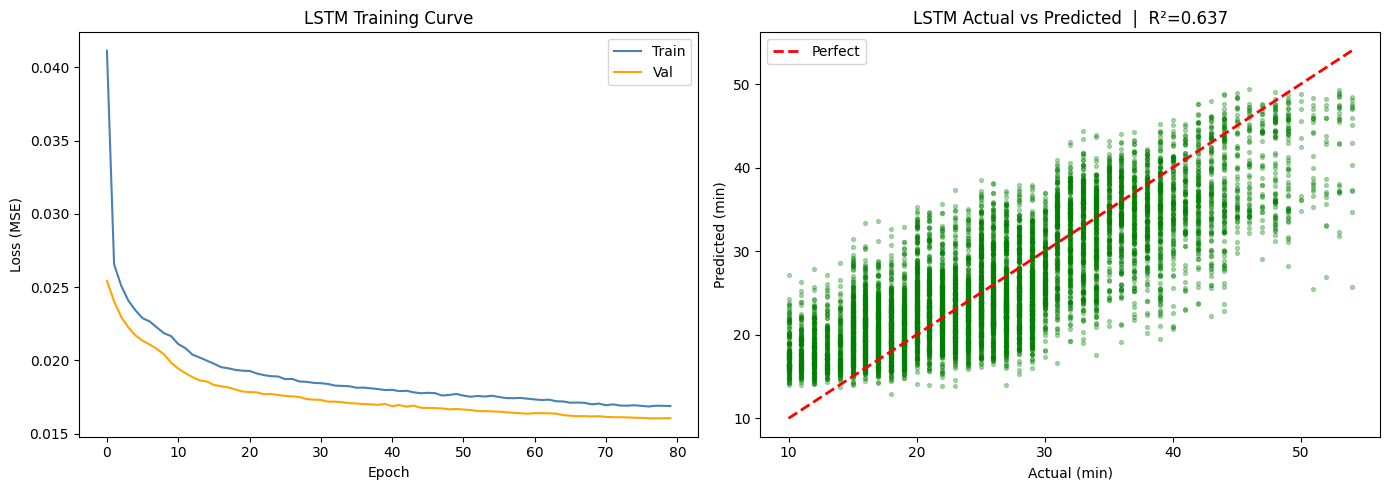

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predict on test set
y_pred_scaled = model.predict(X_test_lstm).flatten()

# Inverse transform back to minutes
y_pred_minutes = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)).flatten()

# Evaluate against RAW (unscaled) y_test
rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred_minutes))
mae  = mean_absolute_error(y_test_raw, y_pred_minutes)
r2   = r2_score(y_test_raw, y_pred_minutes)

print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("📊 LSTM Results")
print(f"   RMSE : {rmse:.2f} min")
print(f"   MAE  : {mae:.2f} min")
print(f"   R²   : {r2:.4f}")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

# Sanity check
print(f"\n🔍 Sanity check:")
print(f"   Actual range   : {y_test_raw.min():.0f} – {y_test_raw.max():.0f} min")
print(f"   Predicted range: {y_pred_minutes.min():.0f} – {y_pred_minutes.max():.0f} min")
print(f"   Actual mean    : {y_test_raw.mean():.1f} min")
print(f"   Predicted mean : {y_pred_minutes.mean():.1f} min")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history.history['loss'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val',   color='orange')
axes[0].set_title('LSTM Training Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()

axes[1].scatter(y_test_raw, y_pred_minutes, alpha=0.3, color='green', s=8)
axes[1].plot([10,54],[10,54], 'r--', lw=2, label='Perfect')
axes[1].set_xlabel('Actual (min)')
axes[1].set_ylabel('Predicted (min)')
axes[1].set_title(f'LSTM Actual vs Predicted  |  R²={r2:.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{PROJECT}/lstm_results.png", dpi=150)
plt.show()

In [ ]:
import pickle

# Load XGBoost
with open(f"{MODELS}/xgboost_model.pkl", 'rb') as f:
    xgb_model = pickle.load(f)

# XGBoost prediction (uses raw unscaled X_test)
xgb_pred      = xgb_model.predict(X_test_raw)

# Ensemble — weighted average
ensemble_pred  = (0.6 * xgb_pred) + (0.4 * y_pred_minutes)

rmse_xgb = np.sqrt(mean_squared_error(y_test_raw, xgb_pred))
rmse_ens  = np.sqrt(mean_squared_error(y_test_raw, ensemble_pred))
mae_ens   = mean_absolute_error(y_test_raw, ensemble_pred)
r2_ens    = r2_score(y_test_raw, ensemble_pred)

print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("🏆 FINAL MODEL LEADERBOARD")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"   Linear Regression → RMSE: 6.72 | R²: 0.48  (baseline)")
print(f"   Random Forest     → RMSE: 4.09 | R²: 0.81")
print(f"   XGBoost           → RMSE: {rmse_xgb:.2f} | R²: 0.82")
print(f"   LSTM              → RMSE: {rmse:.2f} | R²: {r2:.4f}")
print(f"   XGBoost + LSTM    → RMSE: {rmse_ens:.2f} | R²: {r2_ens:.4f}  ⭐")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

improvement = ((6.72 - rmse_ens) / 6.72) * 100
print(f"\n🎯 Improvement over baseline : {improvement:.1f}%")
print(f"   Ensemble RMSE             : {rmse_ens:.2f} min")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏆 FINAL MODEL LEADERBOARD
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Linear Regression → RMSE: 6.72 | R²: 0.48  (baseline)
   Random Forest     → RMSE: 4.09 | R²: 0.81
   XGBoost           → RMSE: 3.99 | R²: 0.82
   LSTM              → RMSE: 5.64 | R²: 0.6374
   XGBoost + LSTM    → RMSE: 4.33 | R²: 0.7866  ⭐
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 Improvement over baseline : 35.6%
   Ensemble RMSE             : 4.33 min


In [ ]:
model.save(f"{MODELS}/lstm_model.h5")

with open(f"{MODELS}/scaler_X.pkl", 'wb') as f:
    pickle.dump(scaler_X, f)
with open(f"{MODELS}/scaler_y.pkl", 'wb') as f:
    pickle.dump(scaler_y, f)

final_results = pd.DataFrame([
    {'Model': 'Linear Regression', 'RMSE': 6.72,           'R2': 0.48},
    {'Model': 'Random Forest',     'RMSE': 4.09,           'R2': 0.81},
    {'Model': 'XGBoost',           'RMSE': round(rmse_xgb,2), 'R2': 0.82},
    {'Model': 'LSTM',              'RMSE': round(rmse,2),   'R2': round(r2,4)},
    {'Model': 'XGBoost+LSTM',      'RMSE': round(rmse_ens,2),'R2': round(r2_ens,4)},
])
final_results.to_csv(f"{PROJECT}/final_leaderboard.csv", index=False)

print("✅ All saved!")
print(f"   lstm_model.h5")
print(f"   scaler_X.pkl + scaler_y.pkl")
print(f"   final_leaderboard.csv")

✅ All saved!
   lstm_model.h5
   scaler_X.pkl + scaler_y.pkl
   final_leaderboard.csv
